In [12]:
## import packages
import numpy as np
import pandas as pd
from PIL import Image
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
import math
from scipy.ndimage import convolve1d
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
from typing import List, Tuple, Optional, Dict, Union

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.linear_model import LogisticRegression

plt.rcParams["figure.figsize"] = (20, 8)

In [13]:
def rgb2gray(rgb: np.ndarray) -> np.ndarray:
    """
    Converts RGB images to grayscale.

    Args:
        rgb (np.ndarray): RGB image.

    Returns:
        gray (np.ndarray): Grayscale image.
    """
    r, g, b = rgb[:, :, 0], rgb[:, :, 1], rgb[:, :, 2]
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b
    return gray

def plot_pictures(
    imgs: List[np.ndarray],
    xlabels: List[str],
    nrows: int,
    ncols: int,
    show: bool = True,
    cmap: Union[str, List[str]] = "gray",
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    same_scale: bool = False,
) -> List[plt.Axes]:
    """
    Plots images in a grid.

    Args:
        imgs (list[np.ndarray]): List of images.
        xlabels (list[str]): List of xlabels.
        nrows (int): Number of rows.
        ncols (int): Number of columns.
        show (bool): Whether to show the plot.
        cmap (Union[str, List[str]]): Color map.
        vmin (float): Minimum value.
        vmax (float): Maximum value.
        same_scale (bool): Whether to use the same scale for all images.

    Returns:
        axs (list[matplotlib.axes._subplots.AxesSubplot]): List of axes.
    """
    fig, axs = plt.subplots(nrows, ncols,
                            width_ratios=[img.shape[1] / img.shape[0] for img in imgs],
                            sharey=same_scale,
                            figsize=(ncols * 4, nrows * 4))
    axs = axs.flatten()

    for i, (img, ax) in enumerate(zip(imgs, axs)):
        if isinstance(cmap, list):
            current_cmap = cmap[i]
        else:
            current_cmap = cmap
        im = ax.imshow(img, cmap=current_cmap, vmin=vmin, vmax=vmax)


        ax.set_title(xlabels[i])
        ax.axis('off')
    #plt.tight_layout()

    if show:
        plt.show()
    else:
        return axs

In [14]:
def gauss1d(sigma: int, filter_size: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Computes the Gaussian filter.

    Args:
        sigma (int): Standard deviation.
        filter_size (int): Filter size, be wary that it is the full size of the filter.

    Returns:
        Gx (np.ndarray): Gaussian filter.
        x (np.ndarray): Array of integer values.
    """
    
    x  = np.arange(-filter_size, filter_size + 1)
    Gx = np.exp(-x**2 / (2 * sigma**2)) / (np.sqrt(2 * np.pi) * sigma)

    
    return Gx, x

def laplace1d(sigma: int, filter_size: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Laplace 1D filter.

    Args:
        sigma (int): Standard deviation.
        filter_size (int): Filter size.

    Returns:
        Lx (np.ndarray): Laplace filter.
        x (np.ndarray): x values.
    """

    x = np.arange(-filter_size, filter_size + 1)
    Lx = (x**2 / sigma**4 - 1 / (sigma**2)) * gauss1d(sigma, filter_size)[0] #(1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-x**2 / (2 * sigma**2))

    return Lx, x

def gauss2d(sigma: int, filter_size: int) -> np.ndarray:
    """
    Computes the Gaussian filter.

    Args:
        sigma (int): Standard deviation.
        filter_size (int): Filter size, be wary that it is the full size of the filter.

    Returns:
        Gx (np.ndarray): Gaussian filter.
        x (np.ndarray): Array of integer values.
    """
    
    x, y = np.meshgrid(np.arange(-filter_size, filter_size + 1),
                       np.arange(-filter_size, filter_size + 1))
    
    gauss_kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2)) / (np.sqrt(2 * np.pi) * sigma)
    
    return gauss_kernel, x, y

def laplace2d(sigma: int, filter_size: int = 3) -> np.ndarray:
    """
    Implement a 2D Laplacian filter.

    Args:
        img (np.ndarray): Input image.
        sigma (int): Standard deviation.
        filter_size (int): Filter size.

    Returns:
        smooth_img (np.ndarray): Smoothed image.
    """

    # Step 1: Define the 2D LoG kernel
    y, x = np.meshgrid(np.arange(-filter_size, filter_size + 1),
                       np.arange(-filter_size, filter_size + 1))
 
    # Calculate 2D LoG formula
    log_kernel = (x**2 + y**2 - 2 * sigma**2) / (sigma**4) * gauss2d(sigma, filter_size)[0]

    return log_kernel, x, y

def derivative2d(sigma: int, filter_size: int = 3) -> np.ndarray:
    """
    Implements the 2D Laplacian of Gaussian filter by leveraging the separability property.

    Args:
        sigma (int): Standard deviation.
        filter_size (int): Filter size.

    Returns:
        derived_img (np.ndarray): Derived image after applying the separable LoG filter.
    """
    
    x = np.array([0, 1, 0], [1, -4, 1], [0, 1, 0])




    return log_kernel

In [53]:
from scipy.ndimage import convolve

def separate(img, sigma):

    # Parameters
    cutoff = int(np.ceil(4 * sigma))

    # Funzione gaussiana (con normalizzazione per la convoluzione 1D)
    x = np.arange(-cutoff, cutoff + 1)
    G = np.exp(-x**2 / (2 * sigma**2)) / (np.sqrt(2 * np.pi) * sigma)

    # Derivata seconda della gaussiana
    d2G = G * (x**2 - sigma**2) / (sigma**4)

    # Convoluzione lungo X per dxx (con d2G)
    dxx_temp = convolve1d(img, d2G, axis=1, mode='reflect')  # Convoluzione lungo X con d2G
    dxx = convolve1d(dxx_temp, G, axis=0, mode='reflect')    # Convoluzione lungo Y con G

    # Convoluzione lungo Y per dyy (con d2G)
    dyy_temp = convolve1d(img, G, axis=1, mode='reflect')    # Convoluzione lungo X con G
    dyy = convolve1d(dyy_temp, d2G, axis=0, mode='reflect')  # Convoluzione lungo Y con d2G

    # Laplaciano del Gaussiano (LoG)
    LoG = dxx + dyy

    return LoG

def whole(img, sigma):

    # Parametri
    cutoff = int(np.ceil(4 * sigma))

    # Coordinate del kernel 2D
    x = np.arange(-cutoff, cutoff + 1)
    y = np.arange(-cutoff, cutoff + 1)
    X, Y = np.meshgrid(x, y)

    # Formula del filtro LoG 2D con normalizzazione
    LoG_kernel = (X**2 + Y**2 - 2*sigma**2) / (sigma**4) * np.exp(-(X**2 + Y**2) / (2 * sigma**2)) / (2 * np.pi * sigma**2)

    # Convoluzione con l'immagine
    LoG_filtered_image = convolve(img, LoG_kernel, mode='reflect')

    return LoG_filtered_image


In [47]:
def laplacefiltering(img: np.ndarray, sigma: int, filter_size: int = 3) -> np.ndarray:
    """
    Implements the 2D Laplacian of Gaussian filter by leveraging the separability property.

    Args:
        img (np.ndarray): Input image.
        sigma (int): Standard deviation.
        filter_size (int): Filter size.

    Returns:
        derived_img (np.ndarray): Derived image after applying the separable LoG filter.
    """
    # Kernel gaussiano 1D
    g_x = gauss1d(sigma, filter_size)[0]
    g_y = gauss1d(sigma, filter_size)[0]
    
    # Derivate seconde del kernel gaussiano 1D (per Laplaciano)
    g_xx = laplace1d(sigma, filter_size)[0]
    g_yy = laplace1d(sigma, filter_size)[0]
    
    # Applica convoluzioni 1D per ottenere il LoG
    # 1. Convoluzione lungo x con derivata seconda rispetto a x
    Ix = convolve1d(img, g_x, axis=1)
    # 2. Convoluzione del risultato lungo y con il gaussiano semplice
    Ix = convolve1d(Ix, g_yy, axis=0)
    
    # 3. Convoluzione lungo y con derivata seconda rispetto a y
    Iy = convolve1d(img, g_y, axis=0)
    # 4. Convoluzione del risultato lungo x con il gaussiano semplice
    Iy = convolve1d(Iy, g_xx, axis=1)
    
    # Somma delle due convoluzioni
    img_log_xy = Ix + Iy
    
    return img_log_xy

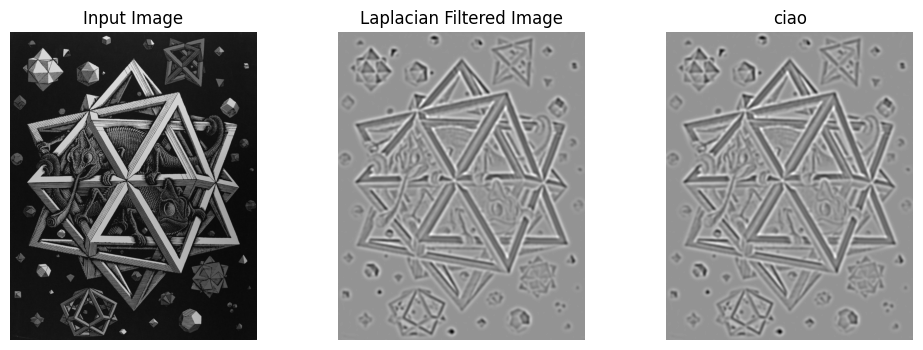

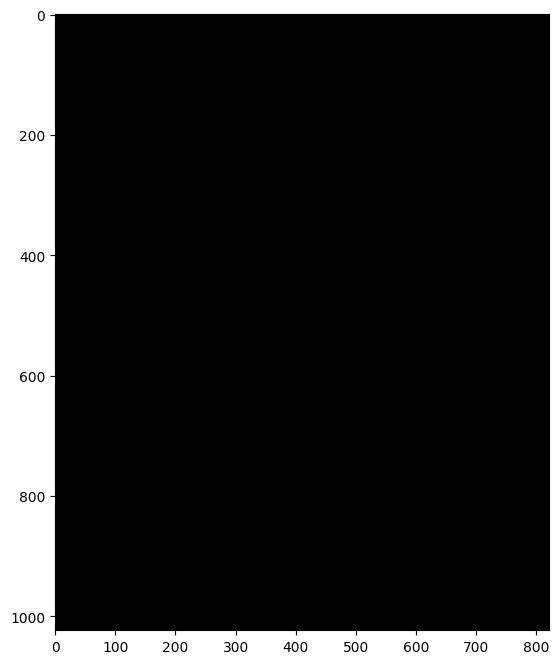

In [54]:
img = rgb2gray(np.array(Image.open("./images/stella.jpg")))
smooth_img_1 = separate(img, 5) #convolve2d(img, laplace2d(5, 10)[0], mode="same")

smooth_img_2 = whole(img, 5) #laplacefiltering(img, 5, 10)

difference_img = smooth_img_1 - smooth_img_2

imgs = [img, smooth_img_2, smooth_img_2]
labels = ["Input Image", "Laplacian Filtered Image", "ciao"]

plot_pictures(imgs, labels, nrows=1, ncols=len(imgs), cmap="gray", vmin=None, vmax=None)
plt.imshow(difference_img * 100, cmap="gray", vmin=0, vmax=255)

In [55]:
np.allclose(separate(img, 5), whole(img, 5))

True